# Assignment: 3.5 Transformers

**Goal:** Use Hugging Face's pretrained sentiment-analysis pipeline to classify Yelp reviews and evaluate how well it matches the dataset labels.

**Tasks:**
- Load and inspect the Yelp review dataset.
- Create and test a pretrained transformer sentiment pipeline.
- Measure accuracy and visualize a confusion matrix.
- Inspect model mistakes and reflect on the approach.

## Step 1: Import Libraries

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, ConfusionMatrixDisplay
from transformers import pipeline

c:\NLP_FSO\.venv-1\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Step 2: Load and Explore the Dataset

Dataset shape: (1000, 2)

Five sample reviews:


,review,opinion
521,If you haven't gone here GO NOW!,1
737,Try them in the airport to experience some tas...,1
740,The restaurant is very clean and has a family ...,1
660,"I personally love the hummus, pita, baklava, f...",1
411,"Come hungry, leave happy and stuffed!",1



Class counts (0 = negative, 1 = positive):
opinion
0    500
1    500
Name: count, dtype: int64

Class percentages:
opinion
0    50.0
1    50.0
Name: count, dtype: float64


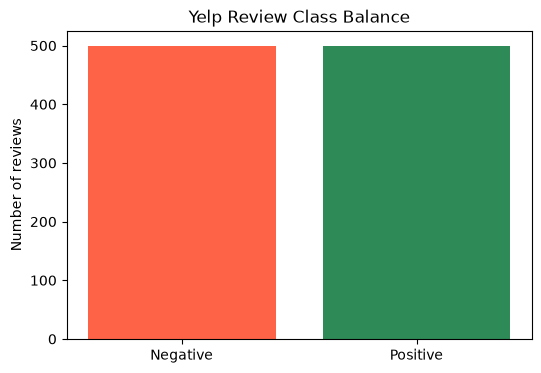

The classes are balanced, so accuracy should be a useful first metric here.


In [2]:
df = pd.read_csv("../NLP/data/yelp-reviews.csv")

print(f"Dataset shape: {df.shape}")
print("\nFive sample reviews:")
display(df.sample(5, random_state=42))

label_counts = df["opinion"].value_counts().sort_index()
label_percentages = (label_counts / len(df) * 100).round(1)
print("\nClass counts (0 = negative, 1 = positive):")
print(label_counts)
print("\nClass percentages:")
print(label_percentages)

plt.figure(figsize=(6, 4))
plt.bar(["Negative", "Positive"], label_counts, color=["tomato", "seagreen"])
plt.title("Yelp Review Class Balance")
plt.ylabel("Number of reviews")
plt.show()

print("The classes are balanced, so accuracy should be a useful first metric here.")

## Step 3: Create and Test the Pipeline

In [3]:
sentiment_analyzer = pipeline("sentiment-analysis")

sample_reviews = df.sample(5, random_state=7).copy()
sample_outputs = sentiment_analyzer(sample_reviews["review"].tolist())
sample_reviews["predicted_label"] = [
    1 if output["label"] == "POSITIVE" else 0 for output in sample_outputs
]
sample_reviews["model_score"] = [output["score"] for output in sample_outputs]

print("The pretrained pipeline returns POSITIVE/NEGATIVE labels, which I map to 1/0 to match this dataset.")
display(sample_reviews[["review", "opinion", "predicted_label", "model_score"]])

[transformers] No model was supplied, defaulted to distilbert/distilbert-base-uncased-finetuned-sst-2-english and revision 714eb0f.
Using a pipeline without specifying a model name and revision in production is not recommended.
c:\NLP_FSO\.venv-1\Lib\site-packages\huggingface_hub\file_download.py:139: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\nolen\.cache\huggingface\hub\models--distilbert--distilbert-base-uncased-finetuned-sst-2-english. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode,

The pretrained pipeline returns POSITIVE/NEGATIVE labels, which I map to 1/0 to match this dataset.


,review,opinion,predicted_label,model_score
778,My girlfriend's veal was very bad.,0,0,0.999800
334,I love this place.,1,1,0.999884
271,You cant go wrong with any of the food here.,1,0,0.985548
802,Why are these sad little vegetables so overcoo...,0,0,0.999186
216,Soggy and not good.,0,0,0.999798


## Step 4: Evaluate the Transformer

Accuracy on the balanced 200-review sample: 94.0%


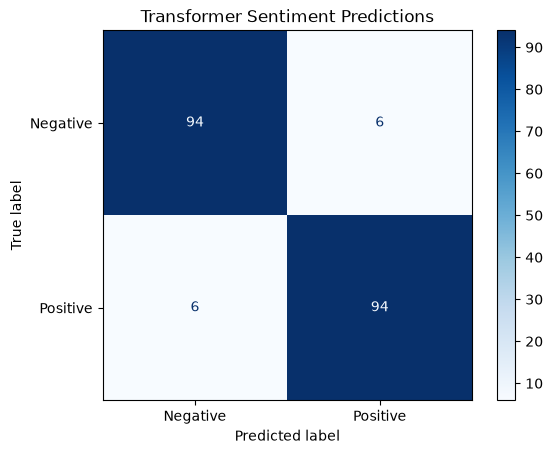

Seeing the errors by class makes the accuracy score much easier to interpret.


In [4]:
# A balanced sample keeps the runtime reasonable while representing both classes equally.
test_df = (
    df.groupby("opinion", group_keys=False)
    .sample(n=100, random_state=42)
    .copy()
)

outputs = sentiment_analyzer(test_df["review"].tolist(), batch_size=16, truncation=True)
test_df["predicted_label"] = [
    1 if output["label"] == "POSITIVE" else 0 for output in outputs
]
test_df["model_score"] = [output["score"] for output in outputs]

accuracy = accuracy_score(test_df["opinion"], test_df["predicted_label"])
print(f"Accuracy on the balanced 200-review sample: {accuracy:.1%}")

ConfusionMatrixDisplay.from_predictions(
    test_df["opinion"],
    test_df["predicted_label"],
    display_labels=["Negative", "Positive"],
    cmap="Blues",
)
plt.title("Transformer Sentiment Predictions")
plt.show()

print("Seeing the errors by class makes the accuracy score much easier to interpret.")

## Step 5: Inspect Model Mistakes

In [5]:
mistakes = test_df[test_df["opinion"] != test_df["predicted_label"]].sort_values(
    "model_score", ascending=False
)

if mistakes.empty:
    print("No mistakes were found in this sample. Try a larger sample to inspect harder reviews.")
else:
    print(f"Mistakes found: {len(mistakes)}")
    display(mistakes[["review", "opinion", "predicted_label", "model_score"]].head(10))

Mistakes found: 12


,review,opinion,predicted_label,model_score
35,The only redeeming quality of the restaurant w...,1,0,0.996781
668,"The owner used to work at Nobu, so this place ...",1,0,0.993081
226,This is an unbelievable BARGAIN!,1,0,0.990776
622,The grilled chicken was so tender and yellow f...,1,0,0.986810
647,Food was average at best.,0,1,0.984685
196,The live music on Fridays totally blows.,0,1,0.983426
837,I have never had such bland food which surpris...,0,1,0.981253
626,Best of luck to the rude and non-customer serv...,0,1,0.972321
473,Don't waste your time here.,0,1,0.855981
950,It wasn't busy at all and now we know why.,0,1,0.788070


## Reflection

### What would I change to improve this model?

I would start by evaluating a larger held-out set and compare this pretrained model with a model fine-tuned on Yelp-style reviews. The pretrained pipeline is convenient, but it was not trained specifically for this dataset. Fine-tuning it on labeled restaurant reviews could help it recognize domain-specific phrases, mixed opinions, and the tone people use in short reviews. I would also examine precision and recall for each label instead of relying only on accuracy.

### How does this differ from Bag of Words or TF-IDF?

Bag of Words and TF-IDF turn a review into counts or weights for individual words, so they mostly lose word order and long-range context. A transformer reads tokens in relation to the surrounding tokens through attention, which gives it a better chance to distinguish phrases like "not good" from "good." I think that contextual behavior is the biggest practical difference: the pretrained transformer already brings language knowledge, while earlier approaches depended much more on the features and classifier I trained from this dataset.

### What might have caused a model mistake?

One clear mistake was **"It wasn't busy at all and now we know why."** The true label is negative, but the model predicted positive with about 79% confidence. I think this review is difficult because its negative meaning is implied instead of stated with an obvious word like "bad." The final phrase, "now we know why," means the empty restaurant was justified by a bad experience, but recognizing that requires connecting the two parts of the sentence and using some real-world context. This is a useful reminder that even a strong transformer can miss indirect criticism.